# Problem set 7: Exchange economies - comments/solutions

# Programming for Economists Summer 2026: Class 9
**Matias BF Hall**

**What you will practice**

* Extending a model you already know: a new **functional form**, more **consumers**, and CES preferences.
* Writing a **subclass** that only overrides what actually changes - and **filling in** a class from a skeleton.
* **Testing** your code with `assert` against cases you can already solve.
* Root-finding with `optimize.root_scalar`, and with two algorithms you write yourself.
* Discovering that a model can have **more than one equilibrium** - and that which one you find depends on the algorithm.
* Making figures with `fig` and `ax` that are easy to read.

**Answers.** After each question there is a cell like `import A1` + `A1.run()`. Write your own code first, then run the answer cell and compare.

**Table of contents**<a id='toc0_'></a>    
- 1. [Supply and demand](#toc1_)    
- 2. [Another functional form](#toc2_)    
- 3. [An exchange economy with many consumers](#toc3_)    
- 4. [More than one equilibrium](#toc4_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [2]:
%load_ext autoreload
%autoreload 2

from types import SimpleNamespace
from scipy import optimize
import numpy as np

import matplotlib.pyplot as plt
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'-'})
plt.rcParams.update({'font.size':14})

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

from Python_scripts.exchange import ExchangeEconomy # the model from lecture 10

**The model from the lecture** is in the file [exchange.py](exchange.py) and was imported above. Use it as a **template** for your own classes - and as a **test** of your new formulas.

In [3]:
model_lecture = ExchangeEconomy()
print(model_lecture)
print('')
print(f'p1* = {model_lecture.equilibrium_price():.6f}')

Exchange economy with:
  alpha = 0.33 (A spends this share of her income on good 1)
  beta  = 0.67 (B spends this share of her income on good 1)
  wA    = (0.80,0.30) (what A owns)
  wB    = (0.20,0.70) (what B owns)

p1* = 0.944444


## 1. <a id='toc1_'></a>[Supply and demand](#toc0_)

Before returning to the exchange economy, a warm-up on the simplest market there is.

The **demand function** $D(p)$ says how much the buyers want at the price $p$, and the **supply function** $S(p)$ how much the sellers offer. We use straight lines,

$$ D(p) = a - bp, \qquad S(p) = c + dp $$

with $a=10$, $b=1$, $c=2$ and $d=1$. **Excess demand** is $Z(p) = D(p)-S(p)$, and the **equilibrium price** $p^{\ast}$ is where it is zero. Here it can be isolated by hand,

$$ p^{\ast} = \frac{a-c}{b+d} $$

which gives us something to test against.

**Question:**

1. Write the three functions `demand(p)`, `supply(p)` and `excess_demand(p)`.
2. Find $p^{\ast}$ with `optimize.root_scalar` and check with an `assert` that it agrees with the formula.
3. Write the **auction algorithm** from section 6 of the lecture as a function `tatonnement(p_guess,nu)` that returns the whole path of prices *and* whether it converged. Start from $p=5$ and try $\nu = 0.05, 0.10, 0.50$ and $1.10$.
4. Make a figure with two panels: the market (supply and demand, with $p^{\ast}$ marked) and the distance $|p_k-p^{\ast}|$ in the auction on a **log** y-axis.

Then explain what goes wrong for the largest $\nu$. Can you say *exactly* which step sizes work here?

**Hints:**

* `optimize.root_scalar(f,bracket=[0,20],method='brentq')`
* Plot the market with the quantity on the x-axis and the price on the y-axis: `ax.plot(demand(p_grid),p_grid)`.
* A log axis cannot show an exact zero. Use `np.fmax(np.abs(path-p_star),1e-16)`.
* Write the update $p_{k+1} = p_k + \nu Z(p_k)$ as a formula in $p_k-p^{\ast}$ and see what happens to the distance in each round.

Analytical equilibrium price: 4.000000, quantity: 6.000000
Numerical equilibrium price: 4.000000, quantity: 6.000000
Step size: 0.05, Converged: True, Iterations: 183, Final price: 4.000000
Step size: 0.1, Converged: True, Iterations: 87, Final price: 4.000000
Step size: 0.5, Converged: True, Iterations: 2, Final price: 4.000000
Step size: 1.1, Converged: False, Iterations: 201, Final price: 6858816903929258.000000


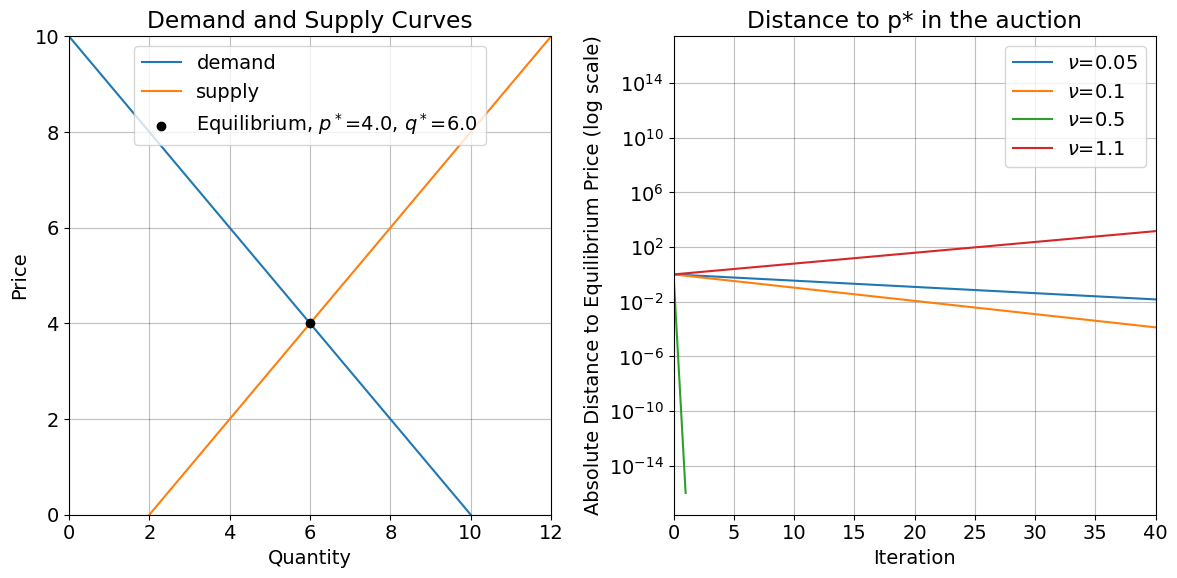

In [4]:
# define parameters
a = 10
b = 1
c = 2
d = 1

# define functions
def demand(p):
    return a - b*p
def supply(p):
    return c + d*p
def excess_demand(p):
    return demand(p) - supply(p)

# compute analytical equilibrium price and quantity
p_star_analytical = (a - c) / (b + d)
q_star_analytical = demand(p_star_analytical)

# compute numerical equilibrium price and quantity using root-finding
p_star_numerical = optimize.root_scalar(excess_demand, bracket=[0, 10]).root
q_star_numerical = demand(p_star_numerical)

# assert that the analytical and numerical equilibrium prices are close
assert np.isclose(p_star_analytical, p_star_numerical), "Analytical and numerical equilibrium prices do not match"

# print the results
print(f"Analytical equilibrium price: {p_star_analytical:.6f}, quantity: {q_star_analytical:.6f}")
print(f"Numerical equilibrium price: {p_star_numerical:.6f}, quantity: {q_star_numerical:.6f}")

# create tatonnement algorithm
def tatonnement(p_guess, nu):
    # create container to store the price guesses
    p_history = [p_guess]
    # run the tatonnement algorithm for a maximum number of iterations
    for i in range(maxiter):
        Z = excess_demand(p_guess) # get excess demand at current price guess
        if abs(Z) < tol: # check if excess demand is within tolerance
            return np.array(p_history), True # return the list as a np array so we can use np functions later. We return True for convergence
        p_guess = p_guess + nu * Z # if we haven't converged yet, update the price guess using the tatonnement rule
        p_history.append(p_guess) # save all wrong guesses to list

    return np.array(p_history), False # Did not converge

# Set parameters for tatonnement and initial guess, p
nu = np.array([0.05, 0.1, 0.5, 1.1])  # Different step sizes for testing
p = 5.0
tol = 1e-8
maxiter = 200

# create grid of prices for plotting
p_grid = np.linspace(0, 10, 100)

# compute demand and supply for the grid of prices
demand_grid = demand(p_grid)
supply_grid = supply(p_grid)

# plot the results
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].plot(demand_grid, p_grid, label=f'demand') # plot demand function
axs[0].plot(supply_grid, p_grid, label=f'supply') # plot supply function
axs[0].scatter(q_star_analytical, p_star_analytical, color='black', label=f'Equilibrium, $p^*$={p_star_analytical:.1f}, $q^*$={q_star_analytical:.1f}', zorder=5) # equilibrium point
axs[0].set_xlabel('Quantity')
axs[0].set_ylabel('Price')
axs[0].set_xlim(0, 12)
axs[0].set_ylim(0, 10)
axs[0].set_title('Demand and Supply Curves')
axs[0].legend()

# run tatonnement for different step sizes and print results and plot
for i, step_size in enumerate(nu): # loop over different step sizes
    # store results
    p_history, converged = tatonnement(p, step_size)
    # print results
    print(f"Step size: {step_size}, Converged: {converged}, Iterations: {len(p_history)}, Final price: {p_history[-1]:.6f}")
    # compute distance using formula given
    distance = np.fmax(np.abs(p_history - p_star_analytical), 1e-16)  # Avoid log(0) by setting a minimum distance
    # plot within loop for each nu
    axs[1].plot(distance, color=colors[i], label=f'$\\nu$={step_size}')
axs[1].set_yscale('log')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel('Absolute Distance to Equilibrium Price (log scale)')
axs[1].set_title('Distance to p* in the auction')
axs[1].set_xlim(0, 40)
axs[1].legend()

fig.tight_layout()
plt.show()

# we see that when the step size is >1 then we don't converge to the equilibrium. When the step size is close to 0, we converge but slowly.

## 2. <a id='toc2_'></a>[Another functional form](#toc0_)

Everything in the lecture rested on **one** choice: that the utility function was Cobb-Douglas. Here we keep the rest of the model exactly as it is - two consumers, one unit of each good, $p_2=1$ - and change only that choice.

Let both consumers have **quasi-linear** preferences,

$$ u^A(x_1,x_2) = a_A\sqrt{x_1} + x_2, \qquad u^B(x_1,x_2) = a_B\sqrt{x_1} + x_2 $$

They are called *quasi-linear* because they are linear in good 2. Good 1 still has falling marginal utility, $\frac{a}{2\sqrt{x_1}}$.

**Demand.** Insert the budget $x_2 = m-p_1x_1$ in the utility function and maximize over $x_1$ alone,

$$ \max_{x_1}\; a\sqrt{x_1} - p_1x_1 + m \qquad\Rightarrow\qquad \frac{a}{2\sqrt{x_1}} = p_1 $$

so that

$$ x_1(p_1) = \left(\frac{a}{2p_1}\right)^{2}, \qquad x_2(p_1,m) = m - p_1x_1(p_1) $$

**Look at that for a moment:** the demand for good 1 does not contain $m$. The income only decides how much is left for good 2.

**The equilibrium price.** Setting $x_1^A + x_1^B = 1$ and isolating $p_1$,

$$ \frac{a_A^2+a_B^2}{4p_1^2} = 1 \qquad\Rightarrow\qquad \boxed{\;p_1^{\ast} = \frac{\sqrt{a_A^2+a_B^2}}{2}\;} $$

**Calibration.** $a_A = 1$ and $a_B = 1.5$, and the endowments are the same as in the lecture, $\omega^A = (0.8,0.3)$.

**Question:** Write a class `QuasiLinearEconomy` that **inherits** from `ExchangeEconomy` and overrides *only* the five methods that actually change: `utility_A`, `utility_B`, `demand_A`, `demand_B` and `equilibrium_price`.

Everything else - `excess_demand`, `solve`, `solve_equilibrium_price` and `tatonnement` - you get for free, because those methods never do anything but call the ones you just replaced. Check that this is true:

1. **Test it:** the formula and the *inherited* `solve_equilibrium_price()` must give the same price.
2. **Test it again:** Walras' law, $p_1\varepsilon_1+\varepsilon_2 = 0$, must still hold at every price, and both markets must clear in equilibrium.
3. Make a figure with two panels: excess demand against the price, and the equilibrium price as a function of $\omega_1^A$ - with the **lecture model** drawn in the same panel for comparison.

Then explain what you see in the right-hand panel. Which line in the formulas above is responsible for it?

**Hints:**

* Inheritance: `class QuasiLinearEconomy(ExchangeEconomy):`, and in `__init__` set the new parameters `self.aA` and `self.aB` *first*, then call `super().__init__(**kwargs)`.
* You may also want to override `__str__`, since the inherited one prints `alpha` and `beta`, which no longer mean anything.
* One economy per endowment: `[QuasiLinearEconomy(w1A=w1A).equilibrium_price() for w1A in w1A_grid]`, and the same with `ExchangeEconomy` for the comparison.
* The methods only do arithmetic, so `model.excess_demand(p1_grid)` works on the whole grid of prices at once - exactly as in section 4.1 of the lecture.

QuasiLinearEconomy(aA=1.0, aB=1.5, endowments for A = (0.8, 0.3), endowments for B = (0.20, 0.70))


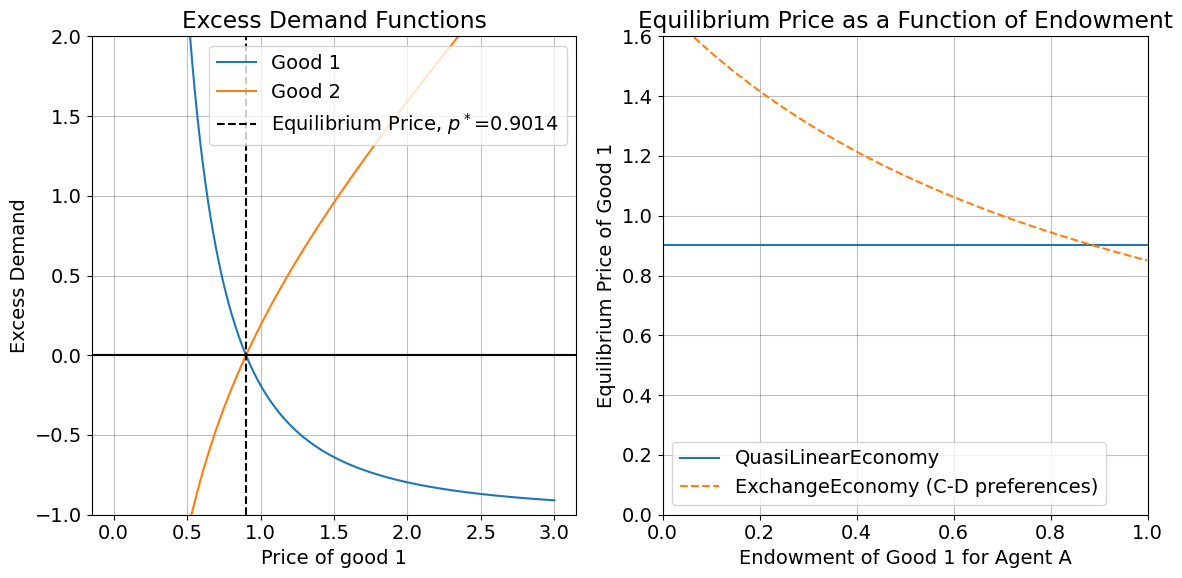

In [10]:
# define the QuasiLinearEconomy class that inherits from ExchangeEconomy
class QuasiLinearEconomy(ExchangeEconomy):
    def __init__(self,**kwargs):
        self.aA = 1.0
        self.aB = 1.5
        super().__init__(**kwargs)
    # override string method. 
    def __str__(self):
        return f"QuasiLinearEconomy(aA={self.aA}, aB={self.aB}, endowments for A = ({self.w1A}, {self.w2A}), endowments for B = ({1-self.w1A:.2f}, {1-self.w2A:.2f}))"

    # override utility functions for agents A and B
    def utility_A(self,x1,x2):
        return self.aA*np.sqrt(x1) + x2
    def utility_B(self,x1,x2):
        return self.aB*np.sqrt(x1) + x2
    
    # override the demand functions for agents A and B
    def demand_A(self,p1):
        m = p1*self.w1A + self.w2A # income for agent A
        x1 = (self.aA/(2*p1))**2
        x2 = m - p1*x1
        return x1, x2 # demand for good 1 and good 2 for agent A
    def demand_B(self,p1):
        m = p1*(1-self.w1A) + (1-self.w2A) # income for agent B
        x1 = (self.aB/(2*p1))**2
        x2 = m - p1*x1
        return x1, x2 # demand for good 1 and good 2 for agent B

    # override the equilibrium price function
    def equilibrium_price(self):
        return np.sqrt(self.aA**2 + self.aB**2)/2

### TESTING ###
# testing is VERY important. When I do these solution I catch many small mistakes I have made. 
# I recommend you also test your code as you go along both in this course but also on yur further journey as a programmer.

# create an instance of the new class and print
model = QuasiLinearEconomy()
print(model)

# 1. solve_equilibrium_price should return the same price as the updated equilibrium_price
assert np.isclose(model.solve_equilibrium_price(), model.equilibrium_price()), "solve_equilibrium_price does not return the same price as equilibrium_price"
# 2. Walras law: p1*e1 + e2 = 0, where e1 and e2 are the excess demands for goods 1 and 2, respectively + market clearing
# create price grid and compute grid of excess demands for goods 1 and 2
p_grid = np.linspace(1e-8, 3, 500) # excess demand is very high/low when p1 is close to 0, so we cut the axis on the plot later to mitigate
e1_grid, e2_grid = model.excess_demand(p_grid)
# assert
assert np.allclose(p_grid*e1_grid + e2_grid, 0.0), "Walras law does not hold for the excess demands at every price"
# find the market equilibrium
sol = model.solve()
# assert that the market clears at the equilibrium price
assert np.isclose(sol.x1A+sol.x1B, 1.0), "Market does not clear for good 1 at the equilibrium price"
assert np.isclose(sol.x2A+sol.x2B, 1.0), "Market does not clear for good 2 at the equilibrium price"
# all tests passed so now we can move on the the next part

# create instance of the lecture model
model_lecture = ExchangeEconomy()

# compute required grids for plotting
# excess demand
eps1_lecture_grid, eps2_lecture_grid = model_lecture.excess_demand(p_grid)
# endowment 1 for A
w1A_grid = np.linspace(1e-8, 0.999, 500)
eq_price_grid = np.array([QuasiLinearEconomy(w1A=w1A).equilibrium_price() for w1A in w1A_grid]) # compute equilibrium price for QuasiLinearEconomy for each endowment of good 1 for agent A using list comprehensions. A for loop would be slower but equally valid.
eq_price_lecture_grid = np.array([ExchangeEconomy(w1A=w1A).equilibrium_price() for w1A in w1A_grid])

# plot

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].plot(p_grid, e1_grid, label='Good 1') # plot excess demand for good 1
axs[0].plot(p_grid, e2_grid, label='Good 2') # plot excess demand for good 2
axs[0].axvline(sol.p1, color='black', linestyle='--', label=f'Equilibrium Price, $p^*$={sol.p1:.4f}') # equlibrium price
axs[0].axhline(0.0,color='black')
axs[0].set_xlabel('Price of good 1')
axs[0].set_ylabel('Excess Demand')
axs[0].set_ylim(-1,2)
axs[0].set_title('Excess Demand Functions')
axs[0].legend()

axs[1].plot(w1A_grid, eq_price_grid, label='QuasiLinearEconomy') # plot equilibrium price for QuasiLinearEconomy
axs[1].plot(w1A_grid, eq_price_lecture_grid, label='ExchangeEconomy (C-D preferences)', ls='--') # plot equilibrium price for ExchangeEconomy
axs[1].set_xlabel('Endowment of Good 1 for Agent A')
axs[1].set_ylabel('Equilibrium Price of Good 1')
axs[1].set_title('Equilibrium Price as a Function of Endowment')
axs[1].set_ylim(0, 1.6)
axs[1].set_xlim(0, 1)
axs[1].legend()

fig.tight_layout()
plt.show()


## 3. <a id='toc3_'></a>[An exchange economy with many consumers](#toc0_)

In the lecture there were exactly **two** consumers. Now there are $N$ of them, $i=1,2,\dots,N$. Everything else is the same:

* consumer $i$ has preferences $u^i(x_1,x_2) = x_1^{\alpha_i}x_2^{1-\alpha_i}$ and owns $(\omega_{1i},\omega_{2i})$
* the price of good 2 is still $p_2 = 1$
* consumer $i$'s income is $m_i = p_1\omega_{1i}+\omega_{2i}$, and her demand is

$$ x_{1i}(p_1) = \alpha_i\frac{m_i}{p_1}, \qquad x_{2i}(p_1) = (1-\alpha_i)\,m_i $$

The **totals** are no longer one of each good but whatever the consumers happen to own together,

$$ W_1 = \sum_{i=1}^N \omega_{1i}, \qquad W_2 = \sum_{i=1}^N \omega_{2i} $$

so **excess demand** is

$$ \varepsilon_1(p_1) = \sum_{i=1}^N x_{1i}(p_1) - W_1, \qquad \varepsilon_2(p_1) = \sum_{i=1}^N x_{2i}(p_1) - W_2 $$

Setting $\varepsilon_1 = 0$ and isolating $p_1$ exactly as in the lecture gives

$$ p_1^{\ast} = \frac{\sum_i \alpha_i\omega_{2i}}{\sum_i (1-\alpha_i)\omega_{1i}} $$

which is the formula from the lecture with the two consumers replaced by $N$ of them.

**The economy used below:**

| $i$ | $\alpha_i$ | $\omega_{1i}$ | $\omega_{2i}$ | |
| --- | --- | --- | --- | --- |
| 1 | 0.20 | 0.90 | 0.10 | owns good 1, wants good 2 |
| 2 | 0.30 | 0.60 | 0.30 | |
| 3 | 0.60 | 0.30 | 0.60 | |
| 4 | 0.80 | 0.10 | 0.90 | owns good 2, wants good 1 |

**Question:** The class below is `ExchangeEconomy` from [exchange.py](exchange.py) rewritten for $N$ consumers. Everything is already in place except **four methods**, and each of them is a **single line**. Fill them in.

The only two changes from the lecture are that `self.alpha` becomes the array `self.alphas`, and that *"A plus B"* becomes a **sum over consumers**.

Then:

1. **Test it:** with $N=2$ and the parameters of the lecture model, your class must give exactly the same price *and* the same allocation as `ExchangeEconomy`.
2. **Test it again:** Walras' law, $p_1\varepsilon_1+\varepsilon_2 = 0$, must hold at every price.
3. **Use it:** solve the economy in the table and make a **bar chart** of what each consumer *owns* and what she *consumes* of good 1. Who buys and who sells?

**Hints:**

* Keep the methods vectorized over consumers: `self.alphas*m/p1` is the demand of *everybody* at once, and `x1.sum()` is the total.
* The lecture model as a special case: `ExchangeEconomyN([m.alpha,m.beta],[m.w1A,1-m.w1A],[m.w2A,1-m.w2A])`.
* Two bars next to each other: `ax.bar(i_grid-0.2,...,width=0.4)` and `ax.bar(i_grid+0.2,...,width=0.4)`.

In [ ]:
class ExchangeEconomyN:
    """ an exchange economy with N consumers, two goods and Cobb-Douglas preferences """

    def __init__(self,alphas,w1,w2,**kwargs):
        """ set the parameters, then overwrite with any keyword arguments """

        # a. parameters, all with one element per consumer
        self.alphas = np.asarray(alphas,dtype=float)
        self.w1 = np.asarray(w1,dtype=float)
        self.w2 = np.asarray(w2,dtype=float)

        # b. useful sizes
        self.N = self.alphas.size # number of consumers
        self.W1 = self.w1.sum() # how much of good 1 exists
        self.W2 = self.w2.sum() # how much of good 2 exists

        # c. overwrite with keyword arguments
        for key,value in kwargs.items():
            setattr(self,key,value)

        # d. empty container for the solution
        self.sol = SimpleNamespace()

    def utility(self,x1,x2):
        """ the utility of every consumer, returns an array with N elements """

        return None # TODO: x1**self.alphas * ...

    def demand(self,p1):
        """ the demand of every consumer at the price p1, returns two arrays with N elements """

        m = p1*self.w1 + self.w2 # the value of what each consumer owns

        return None,None # TODO

    def excess_demand(self,p1):
        """ how much more of each good is wanted than exists, returns (eps1,eps2) """

        x1,x2 = self.demand(p1)

        return None,None # TODO: remember .sum()

    def equilibrium_price(self):
        """ the analytical equilibrium price of good 1 """

        return None # TODO

    def solve_equilibrium_price(self,bracket=[0.01,100.0]):
        """ the equilibrium price, found numerically as the root of excess demand """

        obj = lambda p1: self.excess_demand(p1)[0]
        result = optimize.root_scalar(obj,bracket=bracket,method='brentq')

        return result.root

    def solve(self,p1=None):
        """ store the price, the allocation and the utilities in self.sol """

        if p1 is None: p1 = self.equilibrium_price()

        sol = self.sol
        sol.p1 = p1
        sol.x1,sol.x2 = self.demand(p1)
        sol.u = self.utility(sol.x1,sol.x2) # utility after trading
        sol.u_w = self.utility(self.w1,self.w2) # utility of just keeping the endowment
        sol.gain = sol.u/sol.u_w-1 # the relative gain from trading

        return sol

In [ ]:
# write your own code here

## 4. <a id='toc4_'></a>[More than one equilibrium](#toc0_)

Back to **two** consumers, $A$ and $B$, and two goods, with one unit of each good in total and $p_2=1$ as the numeraire - exactly as in the lecture. The only thing we change is the **utility function**, from Cobb-Douglas to the **CES** form

$$ u(x_1,x_2;\alpha,\beta,\rho) = \left(\alpha x_1^{\rho} + \beta x_2^{\rho}\right)^{1/\rho}, \qquad \rho \neq 0 $$

The indifference curve for the utility level $u$, solved for $x_2$, is

$$ x_2 = \left(\frac{u^{\rho}-\alpha x_1^{\rho}}{\beta}\right)^{\frac{1}{\rho}} $$

and with $\sigma = \frac{1}{1-\rho}$ and $m = p_1\omega_1+\omega_2$ the demand functions are

$$ x_1(p_1,m) = \frac{\alpha^{\sigma}p_1^{-\sigma}\,m}{\alpha^{\sigma}p_1^{1-\sigma}+\beta^{\sigma}}, \qquad
   x_2(p_1,m) = \frac{\beta^{\sigma}\,m}{\alpha^{\sigma}p_1^{1-\sigma}+\beta^{\sigma}} $$

Excess demand and the equilibrium condition are unchanged,

$$ \varepsilon_1(p_1) = x_1^{A}(p_1,m^A) + x_1^{B}(p_1,m^B) - 1 = 0 $$

but this time there is **no formula** for $p_1^{\ast}$ - and, as you will see, no guarantee that there is only one of them either.

**Calibration.** $\alpha^A = \beta^B = 1$, $\beta^A = \alpha^B = (12/37)^3$ and $\rho^A = \rho^B = -2$. The endowments are $\omega_1^A = 1-10^{-8}$ and $\omega_2^A = 10^{-8}$, i.e. $A$ starts with all of good 1 and $B$ with all of good 2.

**Code.** The model is written for you in **[exchangeCES.py](exchangeCES.py)** - preferences, demand and excess demand, in the same style as [exchange.py](exchange.py) from the lecture. What is *missing* is the solvers, and that is what you write here:

```python
from exchangeCES import ExchangeEconomyCES,plot_indifference_A,plot_indifference_B

model = ExchangeEconomyCES()
print(model)
```

**Question:**

1. Make a figure with two panels: the demand for good 1 of each consumer, $x_1^{A}(p_1)$ and $x_1^{B}(p_1)$, and excess demand for good 1, $\varepsilon_1(p_1)$, for $p_1 \in$ `np.linspace(0.25,5,100)`. When is $\varepsilon_1(p_1) \approx 0$? **How many equilibria are there?**

2. Write the **tâtonnement** algorithm from the lecture as a function, with $\tau = 10^{-8}$, $\nu = 50$ and at most $K = 5000$ rounds:

    1. guess $p_1^{0}$ and set $k=0$
    2. calculate $\varepsilon_1^{k} = \varepsilon_1(p_1^{k})$
    3. if $|\varepsilon_1^{k}| < \tau$: stop and return $p_1^{\ast} = p_1^{k}$
    4. if $k > K$: stop and report that it did not converge
    5. set $p_1^{k+1} = p_1^{k} + \nu\varepsilon_1^{k}$
    6. increment $k$ and go back to 2

    Apply it for $p_1^{0} = 0.9$ and $p_1^{0} = 1.1$, and plot the sequences $p_1^{k}$ and $|\varepsilon_1^{k}|$. **Does the guess decide which equilibrium you find?**

3. Apply the same algorithm for all 50 guesses in $p_1^{0} \in$ `np.linspace(0.25,5,50)` and plot $p_1^{0}$ against the resulting $p_1^{\ast}$. **Do you find all the equilibria?**

4. Write a **dampened Newton-Raphson** algorithm with $\tau = 10^{-8}$, $\varphi = 0.1$, $\iota = 0.99$ and $K = 5000$. It is the same loop, except that steps 5-6 are replaced by

    1. calculate the slope $\Delta = \frac{\varepsilon_1(p_1^{k}+h)-\varepsilon_1^{k}}{h}$ for $h = 10^{-6}$
    2. set $p_1^{k+1} = p_1^{k} - \varphi\frac{\varepsilon_1^{k}}{\Delta}$
    3. if $p_1^{k+1} \leq 0$ instead set $p_1^{k+1} = \iota p_1^{k}$

    Apply it for the same 50 guesses and make the same figure. **Do you find all the equilibria now?** Why does this algorithm behave differently?

**Hints:**

* Excess demand is **tiny** here - never more than about $0.006$ in absolute value. That is why $\nu$ has to be as large as $50$, and why you have to look closely at the y-axis to see anything at all in question 1.
* Return *both* the last price and whether the algorithm converged, and collect the whole path in a list, `p1_path.append(p1)`, so you can plot it afterwards.
* A log y-axis cannot show an exact zero: use `np.fmax(np.abs(eps1_path),1e-16)`.
* Once you have found the equilibria in question 1, check that they are exactly $27/64$, $1$ and $64/27$.
* In question 4, think about what the *sign* of the slope $\Delta$ does to the step - and compare it with what the auctioneer does in step 5 above.

In [ ]:
# write your own code here